In [1]:
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import datasets , transforms
from torch.utils.data import random_split , DataLoader
import torch.nn as nn
import torch.optim as optim
import torch

In [2]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

In [3]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [4]:
for params in model.parameters():
    params.requires_grad = False

In [5]:
model.fc = nn.Linear(model.fc.in_features , 2)

In [6]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [7]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

import time, json
from fastdownload import download_url
# dest = './Animal.jpg'
# download_url(urls[0], dest, show_progress=False)

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
from fastai.vision.all import *
# im = Image.open(dest)
# im.to_thumb(256, 256)

searches = 'Damaged Vehicles','New Vehicles'
path = Path('./DamagedvsBranded')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

In [8]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

1

In [9]:
transform = transforms.Compose([transforms.Resize((224,244)) , transforms.ToTensor()])
dataset = datasets.ImageFolder(root= "DamagedvsBranded" , transform=transform) 
dataset.classes , dataset.class_to_idx

(['Damaged Vehicles', 'New Vehicles'],
 {'Damaged Vehicles': 0, 'New Vehicles': 1})

In [10]:
multiplier = 0.7
train_size = int(multiplier * len(dataset))
valid_size = len(dataset) - train_size
train_dataset , valid_dataset = random_split(dataset,[train_size , valid_size])
train_size , valid_size , len(dataset)

(133, 58, 191)

In [11]:
train_loader = DataLoader(train_dataset , batch_size= 32 , shuffle=True)
val_loader = DataLoader(
    valid_dataset,
    batch_size=32
)

In [12]:
# Loss function 
criterion = nn.CrossEntropyLoss()


In [13]:
optimizer = optim.Adam(model.fc.parameters() , lr = 0.001)

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
for epoch in range(20):
    model.train()
    running_loss = 0
    for images , labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()  # it empties the bucket after each batch

        outputs = model(images)
        
        # print(images.shape)
        # print(outputs.shape)
        # print(labels.shape)
        
        loss = criterion(outputs , labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        # print(running_loss , loss.item())
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 0.5649
Epoch 2, Loss: 0.4622
Epoch 3, Loss: 0.5325
Epoch 4, Loss: 0.9290
Epoch 5, Loss: 0.3007
Epoch 6, Loss: 0.4409
Epoch 7, Loss: 0.4267
Epoch 8, Loss: 0.4716
Epoch 9, Loss: 0.2849
Epoch 10, Loss: 0.2322
Epoch 11, Loss: 0.3890
Epoch 12, Loss: 0.2384
Epoch 13, Loss: 0.2925
Epoch 14, Loss: 0.2511
Epoch 15, Loss: 0.3034
Epoch 16, Loss: 0.3669
Epoch 17, Loss: 0.3886
Epoch 18, Loss: 0.4255
Epoch 19, Loss: 0.1959
Epoch 20, Loss: 0.2011


New Vehicles tensor([[0.0160, 0.9840]], device='cuda:0')


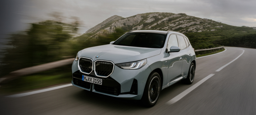

In [31]:
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F
input_path = "./bmw.jpg"
image = Image.open(input_path).convert("RGB")

transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
])

input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)

# print(input_tensor.shape)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
input_tensor = input_tensor.to(device)

model.eval()

class_names = ["Damaged Vehicles", "New Vehicles"]

with torch.no_grad():

    outputs = model(input_tensor)

prob = F.softmax(outputs , dim = 1)

pred = outputs.argmax()

im = Image.open(input_path)
print(class_names[pred.item()] , prob)
im.to_thumb(256, 256)